<a href="https://colab.research.google.com/github/vcardui/RealTimeCharacterDetection/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# +----------------------------------------------------------------------------+
# | CARDUI TECH v1.0.0
# +----------------------------------------------------------------------------+
# | Copyright (c) 2026 - 2026, CARDUITECH.COM (www.carduitech.com)
# | Vanessa Reteguín <vanessa@reteguin.com>
# | Released under the MIT license
# | www.carduitech.com/license/
# +----------------------------------------------------------------------------+
# | Author.......: Vanessa Reteguín <vanessa@reteguin.com>
# | First release: September 16th, 2026
# | Last update..: September 16th, 2026
# | Course.......: Automatons II
# | WhatIs.......: Real Time Character Detection - Main
# +----------------------------------------------------------------------------++
# ------------------------- Instructions -----------------------
# Instrucciones: crea una CNN para clasificar caracteres (conjunto de datos
# "mnist" o "emnist"). Utiliza la red para detectar caracteres en tiempo real.

# ---

# - Detection de caracteres en tiempo real
# - Palabra por palabra vs carácter a carácter

#    Hola = hola = hola.

# - Justificar uso de modelo: Transformer? CNN? Otra?
# - Conclusiones
# - *Entrenar por partes -> Check points

# ------------ Resources / Documentation involved -------------
# MNIST Dataset: https://www.kaggle.com/datasets/hojjatk/mnist-dataset

# Deep learning on MNIST: https://numpy.org/numpy-tutorials/tutorial-deep-learning-on-mnist/

# MNIST Dataset in Python: Complete Guide with Examples:
# https://www.digitalocean.com/community/tutorials/mnist-dataset-in-python$0

# 1. Authenticate with Kaggle API to download datasets

In [2]:
"""
!pip install kaggle -q

from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))

!rm -rf ~/.kaggle
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle/kaggle.json
"""

'\n!pip install kaggle -q\n\nfrom google.colab import files\n\nuploaded = files.upload()\n\nfor fn in uploaded.keys():\n  print(\'User uploaded file "{name}" with length {length} bytes\'.format(name=fn, length=len(uploaded[fn])))\n\n!rm -rf ~/.kaggle\n!mkdir -p ~/.kaggle\n!mv kaggle.json ~/.kaggle/kaggle.json\n!chmod 600 ~/.kaggle/kaggle.json\n!ls ~/.kaggle/kaggle.json\n'

In [3]:
# ------------------------- Libraries -------------------------
import kagglehub # kagglehub.dataset_download(DATASET_ID)

import os  # os.path.exists(path)

import cv2 # camera

import numpy as np
import matplotlib.pyplot as plt

from sklearn import metrics

import tensorflow as tf
from tensorflow.keras import layers, models

In [4]:
# ------------------------- Variables -------------------------
# DATASET_FOLDER = 'input/mnist-dataset/'
DATASET_ID = 'hojjatk/mnist-dataset'

data_sources = {
    "training_images": "train-images-idx3-ubyte",  # 60,000 training images.
    "test_images": "t10k-images-idx3-ubyte",  # 10,000 test images.
    "training_labels": "train-labels-idx1-ubyte",  # 60,000 training labels.
    "test_labels": "t10k-labels-idx1-ubyte",  # 10,000 test labels.
}

In [5]:

DATASET_FOLDER = kagglehub.dataset_download(DATASET_ID)
print(DATASET_FOLDER)

Using Colab cache for faster access to the 'mnist-dataset' dataset.
/kaggle/input/mnist-dataset


Save images and labels into mnist_dataset dictionary as 1D arrays (neural network will expect a 1D array)

Since each image is 28 x 28 pixels, each file is reshaped into a 1 x 784 array

rb = raw binary

In [6]:
mnist_dataset = {}

for key in ("training_images", "test_images"):
    with open(os.path.join(DATASET_FOLDER, f'{data_sources[key]}/{data_sources[key]}'), "rb") as mnist_file:
         # mnist_dataset[key] = np.frombuffer(mnist_file.read(), np.uint8, offset=16).reshape(-1, 28 * 28)
         mnist_dataset[key] = np.frombuffer(mnist_file.read(), np.uint8, offset=16).reshape(-1, 28, 28)

for key in ("training_labels", "test_labels"):
    with open(os.path.join(DATASET_FOLDER, f'{data_sources[key]}/{data_sources[key]}'), "rb") as mnist_file:
        mnist_dataset[key] = np.frombuffer(mnist_file.read(), np.uint8, offset=8)

Split dataset into training and set test

In [7]:
x_train, y_train, x_test, y_test = (
    mnist_dataset["training_images"],
    mnist_dataset["training_labels"],
    mnist_dataset["test_images"],
    mnist_dataset["test_labels"],
)

print(f"""Dataset shapes:
training_images (x_train): {x_train.shape}
training_labels (y_train): {y_train.shape}

test_images (x_test): {x_test.shape}
test_labels (y_test): {y_test.shape}
""")

Dataset shapes:
training_images (x_train): (60000, 28, 28)
training_labels (y_train): (60000,)

test_images (x_test): (10000, 28, 28)
test_labels (y_test): (10000,)



Output:

X (60000, 784) -> (60000 rows, 1 x 784) -> 1D

√ (60000, 28, 28) -> (60000 rows, 28 x 28) -> 2D

Tomar 4 imágenes aleatorias
Pasar de vector 1D (784, ) a 2D (28, 28) -> Poder mostrar imagen 2D

Mostrar imagen en escala de grises

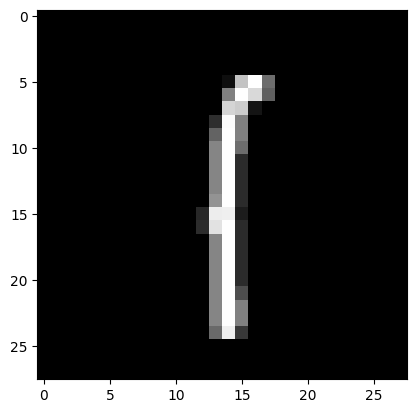

In [8]:
rand = np.random.default_rng().integers(low=0, high=59999, size=1)
mnist_image = x_train[rand, :].reshape(28, 28)

fig, ax = plt.subplots()
ax.imshow(mnist_image, cmap="gray")


# 2. Pre-process the data

## Scaling
Normalize the image's data

8-bit integers [0, 255] -> floating-point [0, 1] interval divided by 255

In [9]:
print('Data type of:\n* Training images: {training_images}\n* Test images: {test_images}'.format(training_images=x_train.dtype, test_images=x_test.dtype))

Data type of:
* Training images: uint8
* Test images: uint8


In [10]:
training_sample = 1000
test_sample = 1000

training_images = x_train[0:training_sample] / 255
test_images = x_test[0:test_sample] / 255

In [11]:
print('Data type of:\n* Training images: {training_images}\n* Test images: {test_images}'.format(training_images=training_images.dtype, test_images=test_images.dtype))

# print(f"Original image: {x_train[0]}\nTraining image: {training_images[0]}")

Data type of:
* Training images: float64
* Test images: float64


## One-hot encoding
Transform floating point class labels into binary vector

Create 10D all-zero vector (number labels 0 to 9)

In [12]:
print('Data type of: \n* Training labels: {training_labels}\n* Test labels: {test_labels}'.format(training_labels=y_train.dtype, test_labels=y_test.dtype))

Data type of: 
* Training labels: uint8
* Test labels: uint8


In [13]:
def one_hot_encoding(labels, dimension=10):
    one_hot_labels = labels[..., None] == np.arange(dimension)[None]

    return one_hot_labels.astype(np.float64)

In [14]:
training_labels = one_hot_encoding(y_train[:training_sample])
test_labels = one_hot_encoding(y_test[:test_sample])

In [15]:
print('Data type of: \n* Training labels: {training_labels}\n* Test labels: {test_labels}'.format(training_labels=training_labels.dtype, test_labels=test_labels.dtype))

print("\nOrginals vs Training labels")
for i in range(0, 3):
  print(f"    {y_train[i]}       {training_labels[i]}")

Data type of: 
* Training labels: float64
* Test labels: float64

Orginals vs Training labels
    5       [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
    0       [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    4       [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [16]:
print(f"""Dataset shapes:
training_images (x_train): {x_train.shape}
training_labels (y_train): {y_train.shape}

test_images (x_test): {x_test.shape}
test_labels (y_test): {y_test.shape}
""")

Dataset shapes:
training_images (x_train): (60000, 28, 28)
training_labels (y_train): (60000,)

test_images (x_test): (10000, 28, 28)
test_labels (y_test): (10000,)



# Crear modelo

In [17]:
model = models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         5,770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,514 (240.29 KB)

 Trainable params: 61,514 (240.29 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training model...")

model.fit(training_images, training_labels, epochs=5, validation_data=(test_images, test_labels))

Training model...
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.3880 - loss: 1.9610 - val_accuracy: 0.6750 - val_loss: 1.1816
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7630 - loss: 0.7711 - val_accuracy: 0.7920 - val_loss: 0.6029
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8550 - loss: 0.4823 - val_accuracy: 0.8430 - val_loss: 0.4794
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.8970 - loss: 0.3444 - val_accuracy: 0.9020 - val_loss: 0.3304
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9220 - loss: 0.2666 - val_accuracy: 0.8690 - val_loss: 0.3878


In [19]:
model.save('cardui_mnist_cnn.keras')
print("Model saved successfully as: cardui_mnist_cnn.keras")

Model saved successfully as: cardui_mnist_cnn.keras


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


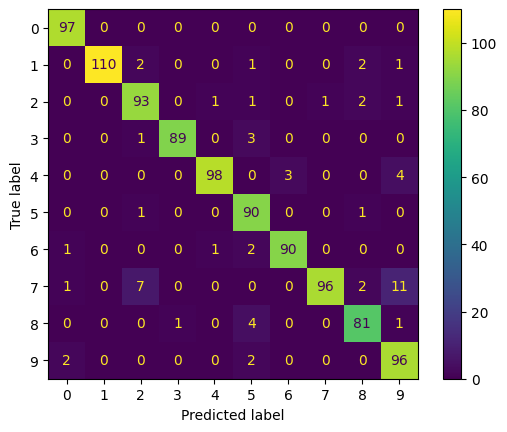

In [20]:
def confusion_matrix(training_images, training_labels):
    labels_prediction = model.predict(training_images)
    labels_prediction_classes = np.argmax(labels_prediction, axis=1)

    if training_labels.ndim > 1:
        true_labels_classes = np.argmax(training_labels, axis=1)
    else:
        true_labels_classes = training_labels

    cm = metrics.confusion_matrix(true_labels_classes, labels_prediction_classes)
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
    cm_display.plot()

confusion_matrix(training_images, training_labels)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8690 - loss: 0.3878
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


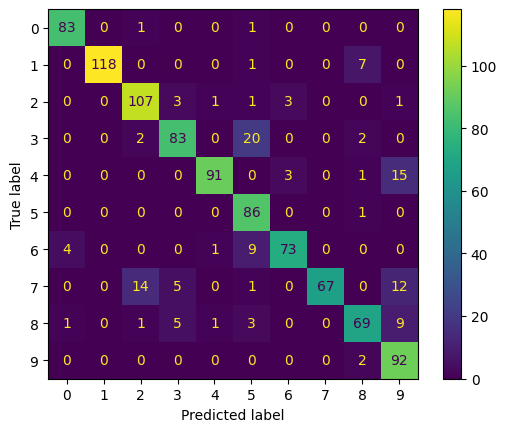

In [22]:
model.evaluate(test_images, test_labels)
confusion_matrix(test_images, test_labels)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


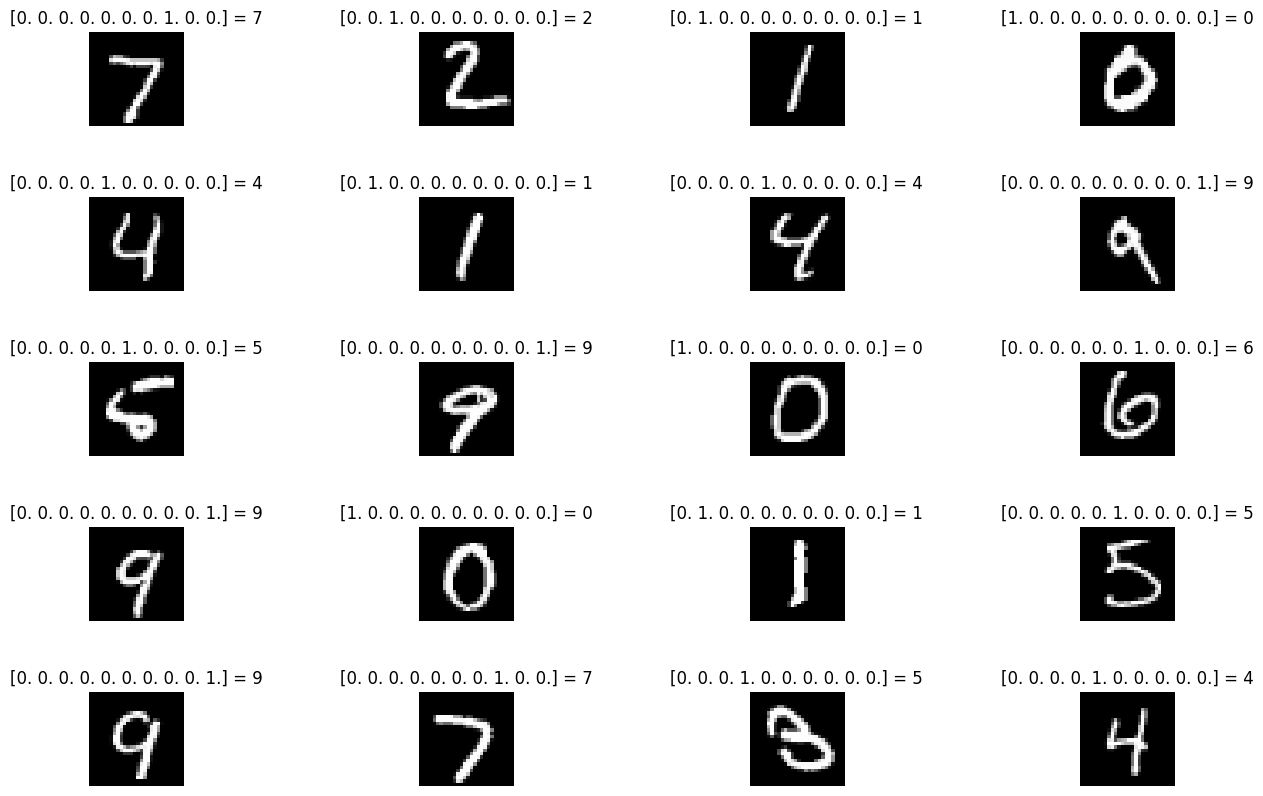

In [98]:
labels_prediciton = np.argmax(model.predict(test_images), axis = 1)
y = [f'{test_labels[i]} = {labels_prediciton[i]}' for i in range(test_labels.shape[0])]
# y = [f'{labels_prediciton[i]}' for i in range(test_labels.shape[0])]

# fig, axes = plt.subplots(5, 3)
cols = 4
rows = 5

fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
fig.subplots_adjust(wspace=2.5, hspace=0.5)


for i in range(rows * cols):
    ax = axes[i // cols, i % cols]

    ax.imshow(test_images[i], cmap = 'gray')
    ax.set_title(y[i], fontsize=12)
    ax.axis('off')

# Recognize characters via camera

In [ ]:
model = tf.keras.models.load_model('cardui_mnist_cnn.keras')

cap = cv2.VideoCapture(0)
